In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [ ]:
import tensorflow as tf
print(tf.keras.__version__)

3.13.2


  Loaded 17,000 images | shape (17000, 28, 28, 1) | labels [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
  Loaded 3,000 images | shape (3000, 28, 28, 1) | labels [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

After flattening:
  X_train : (17000, 784)   y_train (one-hot): (17000, 10)
  X_test  : (3000, 784)    y_test  (one-hot): (3000, 10)


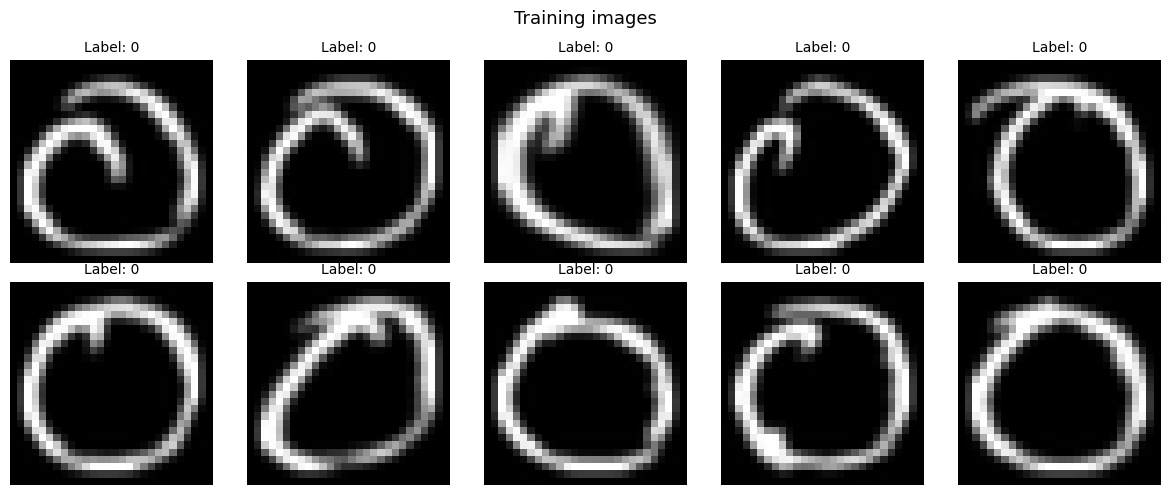

In [ ]:
def load_dataset(folder_path, img_size=(28, 28)):
    """
    Walk through every digit_N sub-folder, load each PNG, return
    normalised image arrays with their integer labels.

    Label is read directly from the folder name:
        digit_0  ->  0
        digit_1  ->  1
        ...
        digit_9  ->  9

    Returns
    -------
    X : float32 ndarray  shape (N, 28, 28, 1)   pixels in [0, 1]
    y : int32   ndarray  shape (N,)              class index 0-9
    """
    images = []
    labels = []

    for folder_name in sorted(os.listdir(folder_path)):
        folder_full = os.path.join(folder_path, folder_name)

        if not os.path.isdir(folder_full):
            continue

        if not folder_name.startswith("digit_"):
            print(f"  Skipping unexpected folder: '{folder_name}'")
            continue

        label = int(folder_name.split("_")[1])

        for img_file in sorted(os.listdir(folder_full)):
            img_path = os.path.join(folder_full, img_file)
            try:
                img = Image.open(img_path).convert("L")
                img = img.resize(img_size, Image.LANCZOS)
                arr = np.array(img, dtype=np.float32) / 255.0
                arr = arr[..., np.newaxis]
                images.append(arr)
                labels.append(label)
            except Exception as e:
                print(f"  Warning - skipped {img_path}: {e}")

    X = np.array(images, dtype=np.float32)
    y = np.array(labels,  dtype=np.int32)
    print(f"  Loaded {len(X):,} images | shape {X.shape} | labels {sorted(set(y.tolist()))}")
    return X, y

TRAIN_DIR = "/content/drive/MyDrive/AIML/DevanagariHandwrittenDigitDataset/Train"
TEST_DIR  = "/content/drive/MyDrive/AIML/DevanagariHandwrittenDigitDataset/Test"

X_train_raw, y_train_raw = load_dataset(TRAIN_DIR)
X_test_raw,  y_test_raw  = load_dataset(TEST_DIR)

NUM_CLASSES = 10

y_train_ohe = to_categorical(y_train_raw, num_classes=NUM_CLASSES)
y_test_ohe  = to_categorical(y_test_raw,  num_classes=NUM_CLASSES)

# Flatten
X_train = X_train_raw.reshape(len(X_train_raw), -1)
X_test  = X_test_raw.reshape(len(X_test_raw),  -1)

shuffle_idx = np.random.RandomState(42).permutation(len(X_train))
X_train = X_train[shuffle_idx]
y_train_ohe = y_train_ohe[shuffle_idx]

print(f"\nAfter flattening:")
print(f"  X_train : {X_train.shape}   y_train (one-hot): {y_train_ohe.shape}")
print(f"  X_test  : {X_test.shape}    y_test  (one-hot): {y_test_ohe.shape}")

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, img, lbl in zip(axes.flat, X_train_raw[:10], y_train_raw[:10]):
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(f"Label: {lbl}", fontsize=10)
    ax.axis("off")
plt.suptitle("Training images", fontsize=13)
plt.tight_layout()
plt.savefig("training_images.png", dpi=120)
plt.show()

In [ ]:

INPUT_DIM = 784

model = keras.Sequential(
    [
        layers.Input(shape=(INPUT_DIM,), name="input"),

        # Hidden layer 1: 64 neurons, sigmoid activation
        layers.Dense(64,  activation="sigmoid", name="hidden_1"),

        # Hidden layer 2: 128 neurons, sigmoid activation
        layers.Dense(128, activation="sigmoid", name="hidden_2"),

        # Hidden layer 3: 256 neurons, sigmoid activation
        layers.Dense(256, activation="sigmoid", name="hidden_3"),

        # Output layer: 10 units (one per Devnagari digit), softmax
        layers.Dense(NUM_CLASSES, activation="softmax", name="output"),
    ],
    name="Devnagari_FCN",
)

model.summary()

Model: "Devnagari_FCN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

print("  Optimizer : Adam")
print("  Loss      : categorical_crossentropy  (labels are one-hot encoded)")
print("  Metric    : accuracy")

  Optimizer : Adam
  Loss      : categorical_crossentropy  (labels are one-hot encoded)
  Metric    : accuracy


Epoch 1/20
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2389 - loss: 2.1786
Epoch 1: val_loss improved from None to 1.08244, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4187 - loss: 1.8622 - val_accuracy: 0.7332 - val_loss: 1.0824
Epoch 2/20
 96/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7994 - loss: 0.8413
Epoch 2: val_loss improved from 1.08244 to 0.41526, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8421 - loss: 0.6535 - val_accuracy: 0.8938 - val_loss: 0.4153
Epoch 3/20
102/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9091 - loss: 0.3579
Epoch 3: val_loss improved from 0.41526 to 0.26866, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9124 - loss: 0.3257 - val_accuracy: 0.9224 - val_loss: 0.2687
Epoch 4/20
 99/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9337 - loss: 0.2421
Epoch 4: val_loss improved from 0.26866 to 0.20045, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9362 - loss: 0.2266 - val_accuracy: 0.9432 - val_loss: 0.2004
Epoch 5/20
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9481 - loss: 0.1836
Epoch 5: val_loss improved from 0.20045 to 0.16198, saving model to best_model.h5


...


Epoch 12: finished saving model to best_model.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9897 - loss: 0.0464 - val_accuracy: 0.9750 - val_loss: 0.0836
Epoch 13/20
105/107 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9909 - loss: 0.0414
Epoch 13: val_loss improved from 0.08357 to 0.08311, saving model to best_model.h5



Epoch 13: finished saving model to best_model.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9909 - loss: 0.0395 - val_accuracy: 0.9718 - val_loss: 0.0831
Epoch 14/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9937 - loss: 0.0308
Epoch 14: val_loss improved from 0.08311 to 0.07764, saving model to best_model.h5



Epoch 14: finished saving model to best_model.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9935 - loss: 0.0323 - val_accuracy: 0.9765 - val_loss: 0.0776
Epoch 15/20
101/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9937 - loss: 0.0270
Epoch 15: val_loss did not improve from 0.07764
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9941 - loss: 0.0274 - val_accuracy: 0.9753 - val_loss: 0.0807
Epoch 16/20
104/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9963 - loss: 0.0225
Epoch 16: val_loss did not improve from 0.07764
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9954 - loss: 0.0235 - val_accuracy: 0.9756 - val_loss: 0.0794
Epoch 17/20
103/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9983 - loss: 0.0178
Epoch 17: val_loss improved from 0.07764 to 0.07644, saving model to best_model.h5



Epoch 17: finished saving model to best_model.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9976 - loss: 0.0184 - val_accuracy: 0.9759 - val_loss: 0.0764
Epoch 18/20
 97/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9976 - loss: 0.0157
Epoch 18: val_loss improved from 0.07644 to 0.07251, saving model to best_model.h5



Epoch 18: finished saving model to best_model.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9975 - loss: 0.0157 - val_accuracy: 0.9774 - val_loss: 0.0725
Epoch 19/20
102/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9985 - loss: 0.0116
Epoch 19: val_loss did not improve from 0.07251
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9985 - loss: 0.0122 - val_accuracy: 0.9747 - val_loss: 0.0766
Epoch 20/20
 96/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9995 - loss: 0.0090
Epoch 20: val_loss did not improve from 0.07251
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9990 - loss: 0.0101 - val_accuracy: 0.9774 - val_loss: 0.0741
Restoring model weights from the end of the best epoch: 18.

  Training finished after 20 epochs.


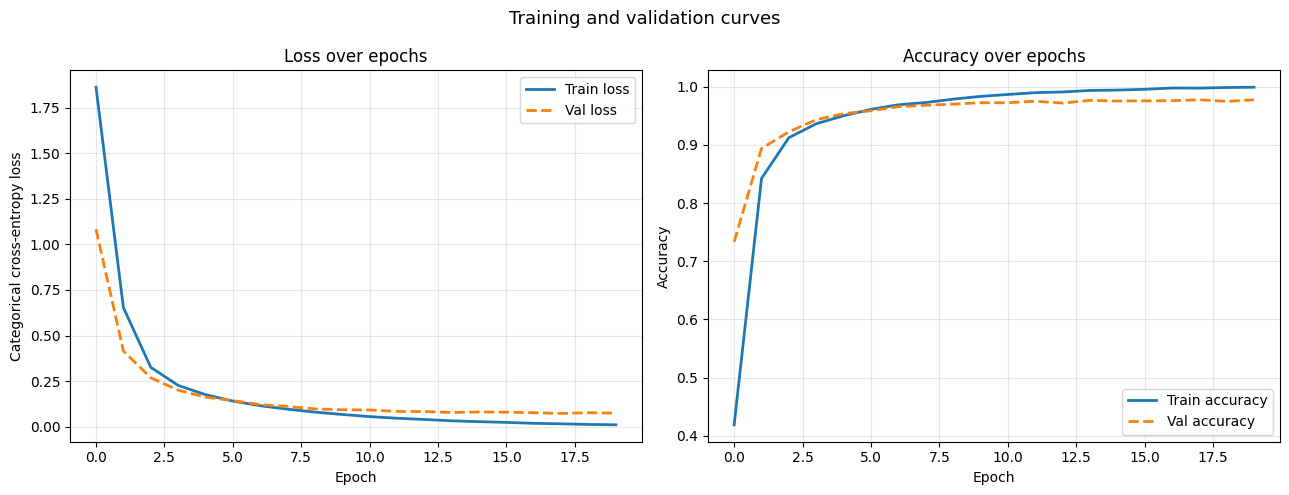

In [ ]:
BATCH_SIZE     = 128
EPOCHS         = 20
VALIDATION_SPLIT = 0.2

# Callback 1: save the best model during training
checkpoint_cb = ModelCheckpoint(
    filepath="best_model.h5",
    monitor="val_loss",
    save_best_only=True,
    verbose=1,
)

# Callback 2: stop early if validation loss stops improving for 5 epochs
early_stop_cb = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1,
)

history = model.fit(
    X_train, y_train_ohe,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=VALIDATION_SPLIT,
    callbacks=[checkpoint_cb, early_stop_cb],
    verbose=1,
)

print(f"\n  Training finished after {len(history.history['loss'])} epochs.")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Loss curve
axes[0].plot(history.history["loss"],     label="Train loss",      linewidth=2)
axes[0].plot(history.history["val_loss"], label="Val loss",        linewidth=2, linestyle="--")
axes[0].set_title("Loss over epochs",     fontsize=12)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Categorical cross-entropy loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(history.history["accuracy"],     label="Train accuracy", linewidth=2)
axes[1].plot(history.history["val_accuracy"], label="Val accuracy",   linewidth=2, linestyle="--")
axes[1].set_title("Accuracy over epochs", fontsize=12)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Training and validation curves", fontsize=13)
plt.tight_layout()
plt.savefig("Training_curves.png", dpi=120)
plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_ohe, verbose=0)

print(f"\n  Test loss     : {test_loss:.4f}")
print(f"  Test accuracy : {test_accuracy * 100:.2f}%")


  Test loss     : 0.0755
  Test accuracy : 97.77%


In [ ]:
SAVE_PATH = "devnagari_fcn_final.h5"
model.save(SAVE_PATH)
print("Model saved")

loaded_model = keras.models.load_model(SAVE_PATH)

reeval_loss, reeval_acc = loaded_model.evaluate(X_test, y_test_ohe, verbose=0)
print(f"\n  Re-evaluated loaded model:")
print(f"    Loss     : {reeval_loss:.4f}")
print(f"    Accuracy : {reeval_acc * 100:.2f}%")

Model saved

  Re-evaluated loaded model:
    Loss     : 0.0755
    Accuracy : 97.77%


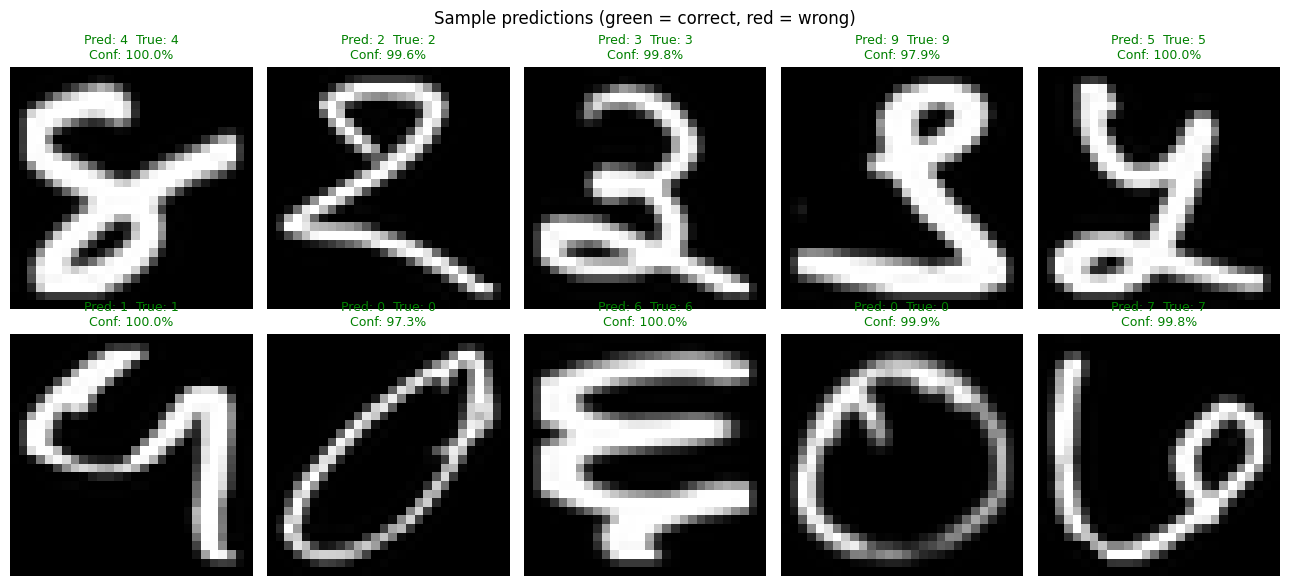


  Final test accuracy : 97.77%
  Saved files:
    best_model.h5               ← best checkpoint during training
    devnagari_fcn_final.h5      ← final trained model
    task1_sample_images.png
    task4_training_curves.png
    task7_predictions.png


In [ ]:
# Get predicted probability distributions for the whole test set
y_prob = loaded_model.predict(X_test, verbose=0)

# Converting probability vectors to predicted class index (0-9)
y_pred = np.argmax(y_prob, axis=1)
y_true = np.argmax(y_test_ohe, axis=1)

fig, axes = plt.subplots(2, 5, figsize=(13, 6))
indices = np.random.choice(len(X_test), 10, replace=False)

for ax, idx in zip(axes.flat, indices):
    ax.imshow(X_test[idx].reshape(28, 28), cmap="gray")
    pred  = y_pred[idx]
    truth = y_true[idx]
    conf  = y_prob[idx][pred] * 100
    color = "green" if pred == truth else "red"
    ax.set_title(f"Pred: {pred}  True: {truth}\nConf: {conf:.1f}%",
                 fontsize=9, color=color)
    ax.axis("off")

plt.suptitle("Sample predictions (green = correct, red = wrong)", fontsize=12)
plt.tight_layout()
plt.savefig("predictions.png", dpi=120)
plt.show()

overall_acc = np.mean(y_pred == y_true) * 100
print(f"\n  Final test accuracy : {overall_acc:.2f}%")

print("  Saved files:")
print("    best_model.h5               ← best checkpoint during training")
print("    devnagari_fcn_final.h5      ← final trained model")
print("    task1_sample_images.png")
print("    task4_training_curves.png")
print("    task7_predictions.png")